In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_ollama import ChatOllama 
from langchain_groq import ChatGroq
from dotenv import load_dotenv
# langchain-groq automatically picks it up from environment

In [4]:
load_dotenv()

True

In [5]:
# model = ChatOllama(model="llama3.2:3b")
model = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [6]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [7]:
def create_outline(state: BlogState) -> BlogState:
    title = state['title']

    prompt = f'Generate an outline for a blog on the topic: {title}'
    outline = model.invoke(prompt).content

    state['outline'] = outline
    return state

In [8]:
def create_blog(state:BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Generate a blog based on the following outline: {outline}'
    content = model.invoke(prompt).content

    state['content'] = content
    return state

In [9]:
graph = StateGraph(BlogState)

graph.add_node('create_outline',create_outline)
graph.add_node('create_blog', create_blog)

graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

In [10]:
initial_state = {'title': 'The future of AI in India'}
final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'The future of AI in India', 'outline': 'Here\'s a suggested outline for a blog on the topic "The Future of AI in India":\n\n**I. Introduction**\n\n* Brief overview of the current state of AI in India\n* Importance of AI in India\'s economic growth and development\n* Thesis statement: India is poised to become a leader in AI adoption and innovation, with significant potential for growth and impact.\n\n**II. Current AI Landscape in India**\n\n* Overview of the current AI ecosystem in India, including:\n\t+ Key players and startups\n\t+ Government initiatives and policies\n\t+ Industry adoption and applications\n* Discussion of the challenges and opportunities facing the Indian AI industry\n\n**III. Emerging Trends in AI in India**\n\n* Discussion of emerging trends and technologies in AI, including:\n\t+ Machine learning and deep learning\n\t+ Natural language processing (NLP)\n\t+ Computer vision\n\t+ Robotics and automation\n* Analysis of how these trends will shape the futu

In [11]:
print(final_state['outline'])

Here's a suggested outline for a blog on the topic "The Future of AI in India":

**I. Introduction**

* Brief overview of the current state of AI in India
* Importance of AI in India's economic growth and development
* Thesis statement: India is poised to become a leader in AI adoption and innovation, with significant potential for growth and impact.

**II. Current AI Landscape in India**

* Overview of the current AI ecosystem in India, including:
	+ Key players and startups
	+ Government initiatives and policies
	+ Industry adoption and applications
* Discussion of the challenges and opportunities facing the Indian AI industry

**III. Emerging Trends in AI in India**

* Discussion of emerging trends and technologies in AI, including:
	+ Machine learning and deep learning
	+ Natural language processing (NLP)
	+ Computer vision
	+ Robotics and automation
* Analysis of how these trends will shape the future of AI in India

**IV. AI in Key Industries in India**

* Discussion of the poten

In [12]:
print(final_state['content'])

**The Future of AI in India: Unlocking Opportunities and Challenges**

**Introduction**

Artificial intelligence (AI) has been transforming industries and economies worldwide, and India is no exception. With a growing pool of skilled talent, a thriving startup ecosystem, and a government that is actively promoting AI adoption, India is poised to become a leader in AI innovation and adoption. In this blog, we will explore the current state of AI in India, emerging trends, government initiatives, and challenges and concerns facing the Indian AI industry.

**Current AI Landscape in India**

India's AI ecosystem is rapidly evolving, with key players and startups emerging in various sectors. Some notable players include:

* **Startups:** AI-powered startups like Haptik, Luminous Infoways, and SigTuple are making waves in areas like conversational AI, computer vision, and healthcare.
* **Government initiatives:** The Indian government has launched several initiatives to promote AI adoption, 

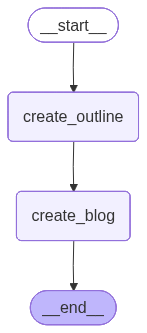

In [13]:
from IPython.display import display, Image
display(Image(workflow.get_graph().draw_mermaid_png()))